In [6]:
%pip install seaborn
%pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [38]:
import numpy as np
import os
from scipy import signal
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt, welch
import pandas as pd


In [ ]:
# DOWNLOAD shared google drive into your local device
# Find the folder in your Library/Finder and click copy or copy path
# paste it into file_path

# Drive:
# file_path = '/content/drive/MyDrive/COGS_189_EEG_Data'

file_path = '/Users/earanda/Downloads/COGS_189_EEG_Data'
 
all_X      = []   # will hold (trials, 8, 225) arrays
all_y      = []   # will hold (trials,) binary label arrays
trial_log  = []   # metadata: sub / ses / run / n_trials / n_errors
 
for sub in sorted(os.listdir(file_path)):
    sub_path = os.path.join(file_path, sub)
    if not (os.path.isdir(sub_path) and sub.startswith('sub-')):
        continue
 
    for ses in sorted(os.listdir(sub_path)):
        ses_path = os.path.join(sub_path, ses)
        if not (os.path.isdir(ses_path) and ses.startswith('ses-')):
            continue
 
        # Collect all run numbers present in this session
        run_nums = set()
        for fname in os.listdir(ses_path):
            if fname.startswith('eeg_trials_run-') and fname.endswith('.npy'):
                run_num = fname.replace('eeg_trials_run-', '').replace('.npy', '')
                run_nums.add(run_num)
 
        for run_num in sorted(run_nums):
            trials_path = os.path.join(ses_path, f'eeg_trials_run-{run_num}.npy')
            labels_path = os.path.join(ses_path, f'labels_run-{run_num}.npy')
 
            # Only load if both files exist
            if not (os.path.exists(trials_path) and os.path.exists(labels_path)):
                print(f"  Skipping {sub}/{ses}/run-{run_num} — missing file")
                continue
 
            X_run = np.load(trials_path, allow_pickle=True)   # (trials, 8, 225)
            y_str = np.load(labels_path, allow_pickle=True)   # (trials,) string
 
            # Handle label shape mismatch (trial_metadata has 50 rows, trials 49)
            # Use the shorter length to keep X and y aligned
            n = min(X_run.shape[0], y_str.shape[0])
            X_run = X_run[:n]
            y_str = y_str[:n]
 
            # Binary encode: error=1, correct=0  (A2 Cell 18 convention)
            y_run = (y_str == 'error').astype(int)
 
            n_err = int(np.sum(y_run))
            n_cor = int(np.sum(y_run == 0))
 
            all_X.append(X_run)
            all_y.append(y_run)
            trial_log.append({
                'sub': sub, 'ses': ses, 'run': run_num,
                'n_trials': n, 'n_errors': n_err, 'n_correct': n_cor
            })
            print(f"  Loaded {sub}/{ses}/run-{run_num}: "
                  f"{n} trials  ({n_cor} correct, {n_err} error)")
 
# concat all the runs

# (total_trials, 8, 225)
X_all = np.concatenate(all_X, axis=0) 
# (total_trials,)
y_all = np.concatenate(all_y, axis=0)  
 
total_trials = X_all.shape[0]
total_errors = int(np.sum(y_all))
total_correct = int(np.sum(y_all == 0))
 
print(f"  Total runs loaded: {len(trial_log)}")
print(f"  Total trials: {total_trials}")
print(f"  Total correct: {total_correct}  ({100*total_correct/total_trials:.1f}%)")
print(f"  Total errors: {total_errors}   ({100*total_errors/total_trials:.1f}%)")
print(f"  X shape: {X_all.shape}")
print(f"  y shape: {y_all.shape}")
 
#parameters for dataset
fs               = 250.0       # Hz
dt               = 1000. / fs  # ms (A1 Cell 39)
sdt              = int(round(dt))
epoch_start_ms   = -500
epoch_end_ms     =  400
pre_start_ms     = -500
pre_end_ms       =   0
baseline_start_ms = -500
baseline_end_ms   = -400
 
pre_s = np.round((pre_start_ms  - epoch_start_ms) / sdt).astype(int)   # 0
pre_e = np.round((pre_end_ms    - epoch_start_ms) / sdt).astype(int)   # 125
bl_s  = np.round((baseline_start_ms - epoch_start_ms) / sdt).astype(int)
bl_e  = np.round((baseline_end_ms   - epoch_start_ms) / sdt).astype(int)
 
channel_names = ['Fz','F3','Cz','C3','C4','Pz','O1','O2']
times_ms = np.linspace(epoch_start_ms, epoch_end_ms, X_all.shape[2])
 
err_idx = np.where(y_all == 1)[0]
cor_idx = np.where(y_all == 0)[0]


  Loaded sub-01/ses-01/run-01: 49 trials  (43 correct, 6 error)
  Loaded sub-01/ses-01/run-02: 50 trials  (44 correct, 6 error)
  Loaded sub-01/ses-01/run-03: 50 trials  (44 correct, 6 error)
  Loaded sub-01/ses-01/run-04: 50 trials  (43 correct, 7 error)
  Loaded sub-02/ses-01/run-01: 50 trials  (48 correct, 2 error)
  Loaded sub-02/ses-01/run-02: 50 trials  (45 correct, 5 error)
  Loaded sub-02/ses-01/run-03: 50 trials  (44 correct, 6 error)
  Loaded sub-02/ses-01/run-04: 50 trials  (46 correct, 4 error)
  Loaded sub-02/ses-02/run-01: 50 trials  (44 correct, 6 error)
  Loaded sub-02/ses-02/run-02: 50 trials  (44 correct, 6 error)
  Loaded sub-02/ses-02/run-03: 50 trials  (46 correct, 4 error)
  Loaded sub-02/ses-02/run-04: 50 trials  (49 correct, 1 error)
  Loaded sub-02/ses-02/run-05: 50 trials  (45 correct, 5 error)
  Loaded sub-02/ses-02/run-06: 50 trials  (45 correct, 5 error)
  Loaded sub-02/ses-02/run-07: 49 trials  (46 correct, 3 error)
  Loaded sub-02/ses-02/run-08: 50 trials

In [33]:
# baseline correction for 3D EEG data
# takes value and subtracts it by the mean of all X values, to normalize it around 0
fs = 250.0       # Hz
dt = 1000. / fs  # ms 
sdt = int(round(dt))
epoch_start_ms = -500
epoch_end_ms = 400
baseline_start_ms = -500
baseline_end_ms = -400

# Convert ms to indices
bl_s  = np.round((baseline_start_ms - epoch_start_ms) / sdt).astype(int)
bl_e  = np.round((baseline_end_ms   - epoch_start_ms) / sdt).astype(int)
 
# Baseline correction
X_bl = X_all.copy()
for i in range(X_bl.shape[0]):              
    for ch in range(X_bl.shape[1]):
        X_bl[i, ch, :] = X_bl[i, ch, :] - np.mean(X_bl[i, ch, bl_s:bl_e])

print(f"Baseline corrected shape: {X_bl.shape}")

Baseline corrected shape: (798, 8, 225)


In [34]:
FS = 250.0   
LOWCUT = 1.0
HIGHCUT = 40.0
BANDPASS_ORDER = 2
NOTCH_FREQ = 60.0
NOTCH_Q = 30.0

def butter_bandpass(lowcut, highcut, fs, order=2):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    return butter(order, [low, high], btype="band", analog=False, output="sos")

def bandpass_filter(data, lowcut, highcut, fs, order=2, axis=-1):
    sos = butter_bandpass(lowcut, highcut, fs, order=order)
    return sosfiltfilt(sos, data, axis=axis)

def notch_filter(data, notch_freq, fs, q=30.0, axis=-1):
    w0 = notch_freq / (fs / 2.0)
    b, a = iirnotch(w0, q)
    return filtfilt(b, a, data, axis=axis)

def average_rereference(data, channel_axis=1):
    return data - np.mean(data, axis=channel_axis, keepdims=True)

def preprocess_eeg_trials(trials, fs=FS, lowcut=LOWCUT, highcut=HIGHCUT,
                          bandpass_order=BANDPASS_ORDER, notch_freq=NOTCH_FREQ, notch_q=NOTCH_Q):
    cleaned = bandpass_filter(trials, lowcut, highcut, fs, order=bandpass_order, axis=2)
    cleaned = notch_filter(cleaned, notch_freq, fs, q=notch_q, axis=2)
    cleaned = average_rereference(cleaned, channel_axis=1)
    return cleaned

# Apply to our baseline-corrected data
X_clean = preprocess_eeg_trials(X_bl)
print(f"Filtered Data Shape: {X_clean.shape}")

Filtered Data Shape: (798, 8, 225)


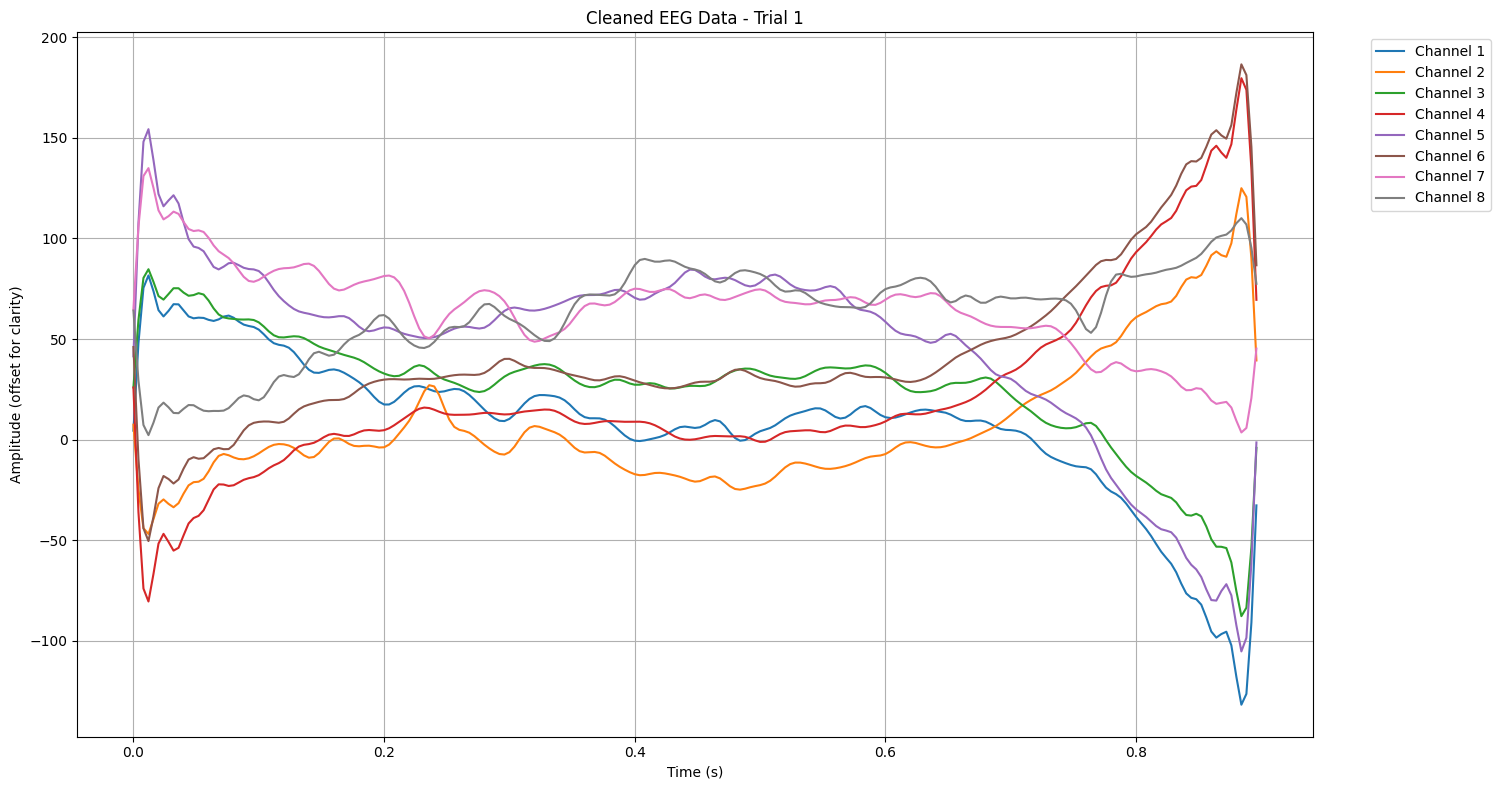

In [35]:
trial_index = 0
single_trial_data = X_clean[trial_index, :, :]

num_channels, num_time_points = single_trial_data.shape
time = np.arange(num_time_points) / FS

plt.figure(figsize=(15, 8))

for i in range(num_channels):
    # Offset each channel by i*10 so they don't overlap
    plt.plot(time, single_trial_data[i, :] + i * 10, label=f'Channel {i+1}') 

plt.title(f'Cleaned EEG Data - Trial {trial_index + 1}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (offset for clarity)')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.grid(True)
plt.tight_layout()
plt.show()

In [36]:
# Filtering
bands = {
    'theta': (4,  7),
    'alpha': (8, 12),
    'beta' : (13, 30),
}
num_taps = 31   # A2 Cell 14

X_bands = {}
for band_name, (hp, lp) in bands.items():
    b = signal.firwin(numtaps=num_taps, cutoff=[hp, lp],
                      pass_zero='bandpass', fs=fs)   # A2 Cell 14
    a = 1                                             # A2 Cell 14: "for FIR filters, a is always 1"

    X_filt = np.zeros_like(X_bl)
    for i in range(X_bl.shape[0]):          # A2 Cell 18: loop over trials
        for ch in range(X_bl.shape[1]):
            X_filt[i, ch, :] = signal.filtfilt(b, a, X_bl[i, ch, :])  # A2 Cell 18

    X_bands[band_name] = X_filt
    print(f"  [{band_name}] ({hp}–{lp} Hz): {X_filt.shape}")


  [theta] (4–7 Hz): (798, 8, 225)
  [alpha] (8–12 Hz): (798, 8, 225)
  [beta] (13–30 Hz): (798, 8, 225)


In [ ]:
CHANNEL_NAMES = ["Fz", "F3", "Cz", "C3", "C4", "Pz", "O1", "O2"]
BANDS = {
    "theta": (4, 7),
    "alpha": (8, 12),
    "beta": (13, 30),
}

def bandpower_1d(x, fs, band, nperseg=None):
    low, high = band
    nperseg = min(len(x), 128) if nperseg is None else nperseg

    freqs, psd = welch(x, fs=fs, nperseg=nperseg)
    mask = (freqs >= low) & (freqs <= high)

    if not np.any(mask): return np.nan

    selected_freqs = freqs[mask]
    selected_psd = psd[mask]

    if selected_freqs.size == 1:
        freq_res = freqs[1] - freqs[0]
        return float(selected_psd[0] * freq_res)

    return float(np.trapezoid(selected_psd, selected_freqs))

def extract_bandpower_features(trials, labels, fs=FS, channel_names=CHANNEL_NAMES, bands=BANDS):
    rows = []
    for trial_idx in range(trials.shape[0]):
        row = {
            "trial": trial_idx,
            "label": "error" if labels[trial_idx] == 1 else "correct"
        }
        trial = trials[trial_idx]

        for ch_idx, ch_name in enumerate(channel_names):
            sig = trial[ch_idx]
            for band_name, band_range in bands.items():
                row[f"{band_name}_{ch_name}"] = bandpower_1d(sig, fs, band_range)

        rows.append(row)

    return pd.DataFrame(rows)

# Generate features directly from memory
feature_table_df = extract_bandpower_features(X_clean, y_all)

display(feature_table_df.head(10))

,trial,label,theta_Fz,alpha_Fz,beta_Fz,theta_F3,alpha_F3,beta_F3,theta_Cz,alpha_Cz,...,beta_C4,theta_Pz,alpha_Pz,beta_Pz,theta_O1,alpha_O1,beta_O1,theta_O2,alpha_O2,beta_O2
0,0,correct,1.321861,3.982295,3.925578,2.267229,7.349736,6.617223,1.861952,2.710826,...,2.583575,1.286651,1.450527,0.703479,1.590990,8.143338,8.366761,7.162659,6.128060,5.191519
1,1,correct,1.734617,1.757569,2.534502,6.112397,1.847448,3.699914,1.097832,0.907777,...,3.778558,1.034208,0.530452,1.025734,4.389171,1.917906,10.746658,4.959751,6.506329,25.598181
2,2,correct,2.824700,1.972858,3.429500,2.118557,4.670550,3.158144,1.444625,0.856548,...,3.963484,2.053247,1.676444,2.542161,4.681856,1.605823,7.680290,4.609148,5.274160,16.539159
3,3,error,6.897308,4.253052,7.120109,3.884163,1.188418,4.766452,0.565722,2.360868,...,4.819920,1.096215,3.606859,1.560819,8.171374,1.248705,10.058953,2.770776,3.685428,12.201979
4,4,correct,2.702984,3.718103,3.425687,2.513052,4.686977,4.916147,2.142155,2.044101,...,4.531310,0.645415,2.461336,1.352353,1.008248,0.961938,5.684733,9.493096,21.416276,12.496606
5,5,correct,1.553619,9.834525,5.513165,2.026588,15.919459,4.830995,2.185345,3.185244,...,5.580925,1.854714,7.248475,1.937224,3.974768,11.406357,4.950427,2.726094,50.600729,24.965741
6,6,correct,13.385953,10.828592,13.781747,5.928327,6.215072,4.224318,0.319995,5.732731,...,1.684278,2.305089,0.917827,0.882894,5.298627,20.348184,10.567571,7.688329,24.660724,26.501730
7,7,error,5.439690,3.208047,6.970203,1.386586,1.976776,3.694780,1.072666,7.344769,...,3.093949,1.435745,3.620669,0.786057,2.188063,4.241243,3.382597,2.429677,30.860121,10.734863
8,8,correct,0.718716,2.192775,3.718931,1.563383,3.861292,8.887599,1.366917,2.111568,...,9.492686,1.019938,0.862091,2.497666,4.777241,6.083944,8.766106,4.293971,15.760727,36.246086
9,9,correct,7.639045,4.734048,8.420313,4.719395,2.703643,4.490602,1.371565,3.762715,...,4.655670,0.652327,1.048674,1.462488,4.889988,6.518577,8.518064,14.169379,2.431210,14.938307
